In [2]:
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.nn.parameter import Parameter
import matplotlib.pyplot as plt

import operator
from functools import reduce
from functools import partial
from timeit import default_timer

import sys, os
sys.path.append(os.path.abspath(".."))  # or the project root path
from HJR_FNO.neural_utils import *

torch.manual_seed(0)
np.random.seed(0)

#### import functions from OptimizedDP

In [3]:
import imp
import numpy as np

# Utility functions to initialize the problem
from HJR_FNO.HJR_FNO import Grid

# Specify the  file that includes dynamic systems
# from odp.dynamics import DubinsCapture, Plane2D, Plane1D, DubinsCar4D
# Plot options
# from odp.Plots import PlotOptions
# from odp.Plots import visualize_plots, plot_isosurface, plot_valuefunction
# # Solver core
# from odp.solver import HJSolver, computeSpatDerivArray

import math
import os

/tmp/ipykernel_18701/2926833911.py:1: DeprecationWarning: the imp module is deprecated in favour of importlib and slated for removal in Python 3.12; see the module's documentation for alternative uses
  import imp


In [4]:

################################################################
#  1d fourier layer
################################################################
class SpectralConv1d(nn.Module):
    def __init__(self, in_channels, out_channels, modes1):
        super(SpectralConv1d, self).__init__()

        """
        1D Fourier layer. It does FFT, linear transform, and Inverse FFT.    
        """

        self.in_channels = in_channels
        self.out_channels = out_channels
        self.modes1 = modes1  #Number of Fourier modes to multiply, at most floor(N/2) + 1

        self.scale = (1 / (in_channels*out_channels))
        self.weights1 = nn.Parameter(self.scale * torch.rand(in_channels, out_channels, self.modes1, dtype=torch.cfloat))

    # Complex multiplication
    def compl_mul1d(self, input, weights):
        # (batch, in_channel, x ), (in_channel, out_channel, x) -> (batch, out_channel, x)
        return torch.einsum("bix,iox->box", input, weights)

    def forward(self, x):
        batchsize = x.shape[0]
        #Compute Fourier coeffcients up to factor of e^(- something constant)
        x_ft = torch.fft.rfft(x)

        # Multiply relevant Fourier modes
        out_ft = torch.zeros(batchsize, self.out_channels, x.size(-1)//2 + 1,  device=x.device, dtype=torch.cfloat)
        out_ft[:, :, :self.modes1] = self.compl_mul1d(x_ft[:, :, :self.modes1], self.weights1)

        #Return to physical space
        x = torch.fft.irfft(out_ft, n=x.size(-1))
        return x

class FNO1d(nn.Module):
    def __init__(self, modes, width):
        super(FNO1d, self).__init__()

        """
        The overall network. It contains 4 layers of the Fourier layer.
        1. Lift the input to the desire channel dimension by self.fc0 .
        2. 4 layers of the integral operators u' = (W + K)(u).
            W defined by self.w; K defined by self.conv .
        3. Project from the channel space to the output space by self.fc1 and self.fc2 .
        
        input: the solution of the initial condition and location (a(x), x)
        input shape: (batchsize, x=s, c=2)
        output: the solution of a later timestep
        output shape: (batchsize, x=s, c=1)
        """

        self.modes1 = modes
        self.width = width
        
        self.lifting = nn.Conv1d(5, self.width, 1)
        self.projection = nn.Conv1d(self.width, 1, 1)

        self.conv0 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv1 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv2 = SpectralConv1d(self.width, self.width, self.modes1)
        self.conv3 = SpectralConv1d(self.width, self.width, self.modes1)
        self.w0 = nn.Conv1d(self.width, self.width, 1)
        self.w1 = nn.Conv1d(self.width, self.width, 1)
        self.w2 = nn.Conv1d(self.width, self.width, 1)
        self.w3 = nn.Conv1d(self.width, self.width, 1)


    def forward(self, x):
        
        #Lifting
        x = x.permute(0, 2, 1)
        x = self.lifting(x)
        
        #Fourier Block 0
        x1 = self.conv0(x)
        x2 = self.w0(x)
        x = x1 + x2
        x = F.relu(x)
        
        #Fourier Block 1
        x1 = self.conv1(x)
        x2 = self.w1(x)
        x = x1 + x2
        x = F.relu(x)
        
        #Fourier Block 2
        x1 = self.conv2(x)
        x2 = self.w2(x)
        x = x1 + x2
        x = F.relu(x)
        
        #Fourier Block 3
        x1 = self.conv3(x)
        x2 = self.w3(x)
        x = x1 + x2
        x = F.relu(x)
        
        #Projection
        x = self.projection(x)
        x = x.permute(0, 2, 1)

        return x

In [4]:
def extract_inputTrain(loader, key='obs_all'):
    return np.stack([loader.data[key][i][0]
                     for i in range(len(loader.data[key]))], axis=0)
    
def extract_outputTrain(loader):
    return np.stack([loader.data['BRT_all'][i][0]
                     for i in range(len(loader.data['BRT_all']))], axis=0)
    
    

'''
About the reachable set

Inside Safe Region l(x) <= 0
Outside the Obstacle g(x) >= 0    same thing as   -1*data['obs_all']

Intersection of both max( g(x), l(x) ) = g(x) >= 0

If there's no obstacle, then l(x) <= 0 should be the input
'''

################################################################
# read data
################################################################

dataloader1 = MatReader('HJB_training_mat/Plane_training_disturbance[01_01_01]_v[0_1]_w[1].mat')

# dataloader2 = MatReader('HJB_training_mat/Plane_1Obs_noIntersection.mat')
# dataloader3 = MatReader('HJB_training_mat/001_Plane_1Obs_noIntersection.mat')
# dataloader3 = MatReader('HJB_training_mat/Plane_3Obs_nointersection.mat')


# dataloader1 = MatReader('HJB_training_mat/Plane_1Obs_Distfree_Sol.mat')
# dataloader2 = MatReader('HJB_training_mat/001_Plane_1Obs_Distfree_Sol.mat')

# dataloader3 = MatReader('HJB_training_mat/Plane_3Obs_Distfree_Sol.mat')
# dataloader4 = MatReader('HJB_training_mat/001_Plane_3Obs_Distfree_Sol.mat')

# dataloader5 = MatReader('HJB_training_mat/Plane_NoObs_posV_Sol.mat')


# concatenate along batch dimension
y_data = np.concatenate([ extract_outputTrain(dataloader1) , #extract_outputTrain(dataloader2), 
                          # extract_outputTrain(dataloader3), extract_outputTrain(dataloader4) #, 
                        #   extract_outputTrain(dataloader5) 
                          ], axis=0)

x_data = np.concatenate([ extract_inputTrain(dataloader1) , #extract_inputTrain(dataloader2), 
                        #  extract_inputTrain(dataloader3), extract_inputTrain(dataloader4) #,
                        #   extract_inputTrain(dataloader5, key="V0_all") 
                          ], axis=0)

# y_data_test = np.concatenate([ extract_outputTrain(dataloader2) ,extract_outputTrain(dataloader3), 
#                           # extract_outputTrain(dataloader3), extract_outputTrain(dataloader4) #, 
#                         #   extract_outputTrain(dataloader5) 
#                           ], axis=0)

# x_data_test = np.concatenate([ extract_inputTrain(dataloader2) , extract_inputTrain(dataloader3), 
#                         #  extract_inputTrain(dataloader3), extract_inputTrain(dataloader4) #,
#                         #   extract_inputTrain(dataloader5, key="V0_all") 
#                           ], axis=0)

print("data outp", y_data.shape)
print("data inp", x_data.shape)

data outp (100, 50, 50, 25, 33)
data inp (100, 50, 50, 25)


### Visualize dataset

In [5]:
import numpy as np
import matplotlib.pyplot as plt


def plot_levelset_2d(
    g,
    reachable_set: np.ndarray,
    title_txt="Level-set Boundary",
    fig: plt.Figure | None = None,
    level_value: float = 0.0,
    line_color: str = "magenta",
    show_color_bar = False
):
    """
    Plot a level set boundary V(x) = level_value of a 2D reachable set.

    Parameters
    ----------
    g : Grid
        Must define pts_each_dim, grid_points, min, max.
    reachable_set : np.ndarray
        2D array of shape (Nx, Ny).
    title_txt : str
        Plot title.
    fig : matplotlib.figure.Figure or None
        If provided, plot on this figure (hold-on mode).
    level_value : float
        The level-set value to contour. Default is 0.
    line_color : str
        Color of the contour line. Default is magenta.
    """

    assert (
        len(reachable_set.shape) == 2
        and reachable_set.shape[0] == g.N[0]
        and reachable_set.shape[1] == g.N[1]
    ), f"Reachable set must be 2D of size {g.N[0:2]}"

    # ---------------------------------------------------------
    # Use existing figure or create a new one
    # ---------------------------------------------------------
    if fig is not None:
        ax = fig.gca()
    else:
        fig, ax = plt.subplots(figsize=(6, 5))

    # ---------------------------------------------------------
    # Meshgrid
    # ---------------------------------------------------------
    X, Y = np.meshgrid(g.vs[0], g.vs[1], indexing="ij")

    # ---------------------------------------------------------
    # Contour plot: V(x) = level_value
    # ---------------------------------------------------------
    CS = ax.contour(
        X,
        Y,
        reachable_set,
        levels=[level_value],
        colors=line_color,
        linewidths=2
    )
    
    contourf = ax.contourf(X, Y, reachable_set, levels=50, cmap="Blues", 
                              vmin=np.min(reachable_set), vmax=np.max(reachable_set), alpha=0.8)
    if show_color_bar:
        cbar = plt.colorbar(contourf, ax=ax, fraction=0.046, pad=0.04)
        cbar.set_label('Value Function', fontsize=11)


    # ---------------------------------------------------------
    # Axes formatting
    # ---------------------------------------------------------
    ax.set_title(f"{title_txt}: V(x) = {level_value}")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_xlim(g.min[0], g.max[0])
    ax.set_ylim(g.min[1], g.max[1])
    ax.grid(True)

    return fig, ax, CS


def shapeCylinder(g, ignoreDims=None, center=None, radius=1.0):
    """
    Create a cylindrical signed distance function on the grid.

    @params
    - ignoreDims: list[int], ignored dimensions
    - center: array-like, cylinder center
    - radius: float, cylinder radius

    @return
    - sdf: signed distance field with shape g.N
    """


    dim = g.dim

    # Default arguments
    if ignoreDims is None:
        ignoreDims = []

    if center is None:
        center = np.zeros(dim)

    ignoreDims = set(ignoreDims)

    # Allocate signed distance array
    data_shape = tuple(g.N)
    dist_squared = np.zeros(data_shape)

    # Accumulate squared distance over ACTIVE dimensions
    for i in range(dim):
        if i not in ignoreDims:
            dist_squared += (g.xs[i] - center[i])**2

    # Euclidean norm in active dimensions
    dist = np.sqrt(dist_squared)

    # Signed distance function (negative inside)
    sdf = dist - radius

    return sdf


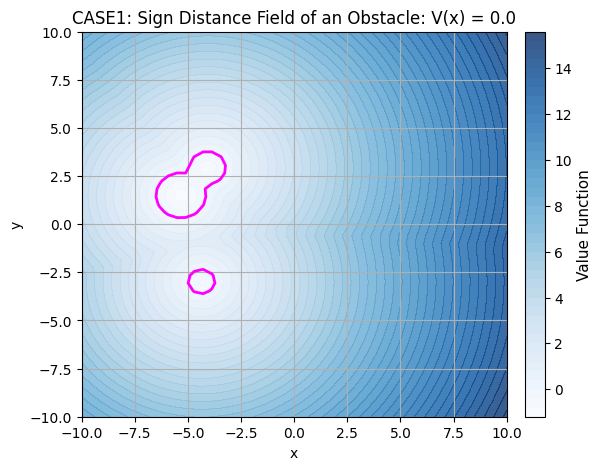

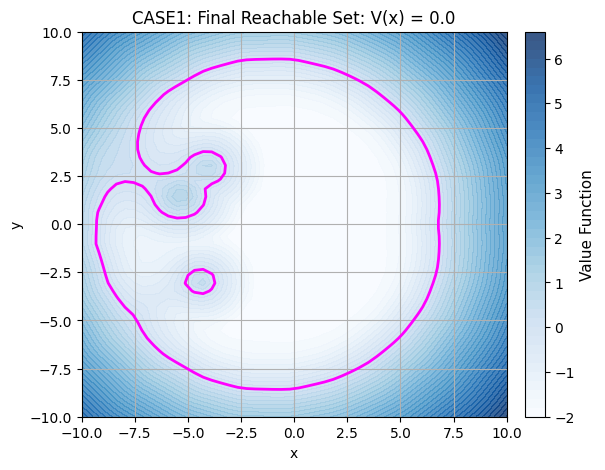

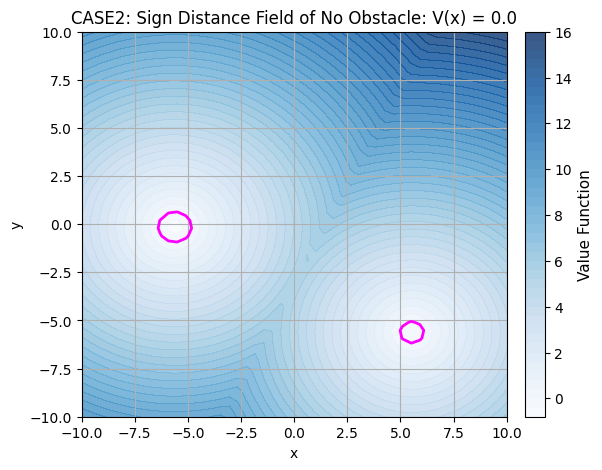

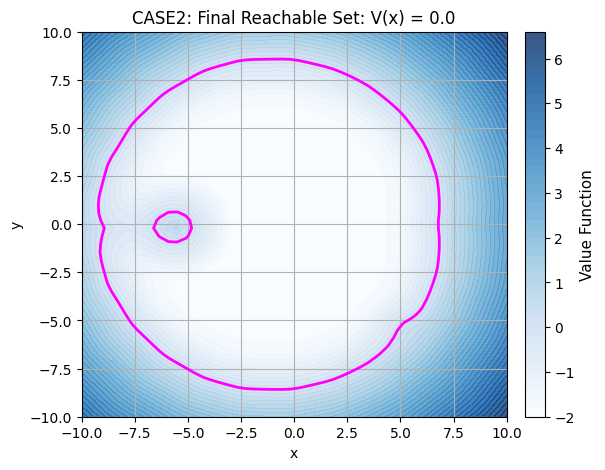

In [6]:
   
#Define Grid
grid_min = np.array([-10.0, -10.0, 0])
grid_max = np.array([10.0, 10.0, 2*math.pi])
N = np.array([50, 50, 25])
pd=[2] #periodic
g = Grid(grid_min, grid_max, N, pd)

#visualize training data
sample_idx = 40
theta_idx = 0
SDF_plot = plot_levelset_2d(g, x_data[sample_idx,:,:,theta_idx], title_txt='CASE1: Sign Distance Field of an Obstacle', show_color_bar=True)
Final_HJR_plot = plot_levelset_2d(g, y_data[sample_idx,:,:,theta_idx, -1], title_txt='CASE1: Final Reachable Set', show_color_bar=True)

SDF_plot = plot_levelset_2d(g, x_data[-1,:,:,theta_idx], title_txt='CASE2: Sign Distance Field of No Obstacle', show_color_bar=True)
Final_HJR_plot = plot_levelset_2d(g, y_data[-1,:,:,theta_idx, -1], title_txt='CASE2: Final Reachable Set', show_color_bar=True)


In [7]:
################################################################
#  Split Train and Test data
################################################################

N = x_data.shape[0] 
perm = np.random.permutation(N)

train_ratio = 0.90   # 95% train
N_train = int(train_ratio * N)

train_idx = perm[:N_train]
test_idx  = perm[N_train:]

x_train = x_data[train_idx,...]
y_train = y_data[train_idx,...]

x_test  = x_data[test_idx,...]
y_test  = y_data[test_idx,...]

print("data input", x_train.shape)
print("data output", y_train.shape)


data input (90, 50, 50, 25)
data output (90, 50, 50, 25, 33)


In [8]:
################################################################
#  Append Training data with 5 Spatial Channels (V, x ,y ,theta, t)
################################################################

# Build 2D meshgrid
X, Y = np.meshgrid(g.vs[0], g.vs[1], indexing="ij")
X_flat = X.reshape(-1)
Y_flat = Y.reshape(-1)

# grid sample for theta and time vars
# NOTE Discretization here must match with the training reachable set
theta_hyparam = np.linspace(0,2*math.pi,25)
time_hyparam = np.linspace(0,8,33)

stride = 4 #for subsampling the theta and time hyperparameters
theta_i = range(len(theta_hyparam[:-1]))
time_i = range(len(time_hyparam))[::4]

batchSize = len(train_idx) * len(theta_i) * len(time_i)
allGridPoints = len(g.vs[0]) * len(g.vs[1]) #spatial XY discretization in the training reachable set 
downSampleGridSize = 2000 #down-sampling from 50x50 to subset grid points
channel = 5

xx_train = torch.empty(batchSize, downSampleGridSize, channel) 
yy_train = torch.empty(batchSize, downSampleGridSize) 


j = 0

for train_i in range(len(train_idx)):
    for t_i in time_i:
        for th_i in theta_i:      
            idx_downSamp = np.sort(np.random.permutation(allGridPoints)[:downSampleGridSize])
            
            SDF_input_sliced = x_train[train_i, :, :, th_i].reshape(-1)
            reachable_set_sliced = y_train[train_i, :, :, th_i, t_i].reshape(-1)
            
            # 5 inputs channels: (V, x ,y ,theta, t)
            # Each channel contains down-sampled number of data from the original reachable set 
            xx_train[j,:,0] = torch.tensor(SDF_input_sliced[idx_downSamp])
            xx_train[j,:,1] = torch.tensor(X_flat[idx_downSamp])
            xx_train[j,:,2] = torch.tensor(Y_flat[idx_downSamp])
            xx_train[j,:,3] = theta_hyparam[th_i] * torch.ones(downSampleGridSize)
            xx_train[j,:,4] = time_hyparam[t_i] * torch.ones(downSampleGridSize)
            
            # output: Final 2D Reachable set at theta slice 'th_i' and at current time 't_i'
            yy_train[j,...] = torch.tensor(reachable_set_sliced[idx_downSamp])
                
            j += 1
         
         
################################################################
#  Append TESTING data with 5 Spatial Channels (V, x ,y ,theta, t)
################################################################   
batchSize = len(test_idx) * len(theta_i) * len(time_i)
xx_test = torch.empty(batchSize, allGridPoints, channel) 
yy_test = torch.empty(batchSize, allGridPoints) 

j = 0

for test_i in range(len(test_idx)):
    for t_i in time_i:
        for th_i in theta_i:  
                        
            SDF_input_sliced = x_test[test_i, :, :, th_i].reshape(-1)
            reachable_set_sliced = y_test[test_i, :, :, th_i, t_i].reshape(-1)
            
            # 5 inputs channels: (V, x ,y ,theta, t)
            # Each channel contains down-sampled number of data from the original reachable set 
            xx_test[j,:,0] = torch.tensor(SDF_input_sliced)
            xx_test[j,:,1] = torch.tensor(X_flat)
            xx_test[j,:,2] = torch.tensor(Y_flat)
            xx_test[j,:,3] = theta_hyparam[th_i] * torch.ones(allGridPoints)
            xx_test[j,:,4] = time_hyparam[t_i] * torch.ones(allGridPoints)
            
            # output: Final 2D Reachable set at theta slice 'th_i' and at current time 't_i'
            yy_test[j,...] = torch.tensor(reachable_set_sliced)
                
            j += 1
            
        




In [9]:
xx_train.shape

torch.Size([19440, 2000, 5])

In [10]:
yy_train.shape

torch.Size([19440, 2000])

In [11]:
################################################################
#  configurations
################################################################
ntrain = xx_train.shape[0]
ntest = yy_train.shape[0]

sub = 4 #subsampling rate
h = 2**13 // sub #total grid size divided by the subsampling rate
s = h

batch_size = 32 #len(theta_i)*len(time_i)
learning_rate = 1e-4 #0.001

epochs = 400#80
step_size = 100 #100
gamma = 0.5

modes = 16
width = 64


# train_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(xx_train, yy_train), batch_size=batch_size, shuffle=True)

train_loader = torch.utils.data.DataLoader(
    torch.utils.data.TensorDataset(xx_train, yy_train),
    batch_size=batch_size,
    shuffle=True,
    pin_memory=True,
    num_workers=4,
    persistent_workers=True
)

test_loader = torch.utils.data.DataLoader(torch.utils.data.TensorDataset(xx_test, yy_test), batch_size=batch_size, shuffle=False)

# model
model = FNO1d(modes, width).cuda()

In [12]:
len(train_loader)

608

### Load/ Train model

In [ ]:
################################################################
# training and evaluation
################################################################
import os
from tqdm import tqdm

def smooth_linf_loss(out, y, alpha):
    """
    out, y: (B, N)
    """
    err = torch.abs(out - y)
    # stabilize logsumexp by subtracting max
    m = err.max(dim=1, keepdim=True)[0]
    return (m + torch.log(torch.mean(torch.exp(alpha * (err - m)), dim=1, keepdim=True)) / alpha).mean()


train_with_Linf = True


# save_path = './model/hjrno_dubins'
save_path = '/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/test/model/hjrno_dubins_PlaneDisturb'
checkpoint_path = '/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/test/model/linf_finetune.pt'


if os.path.exists(save_path):   
    
    print("Loading saved model...")
    model = torch.load(save_path, weights_only=False)
    
    myloss = LpLoss(size_average=False)
    
elif train_with_Linf:
    
    # ============================
    # Hyperparameters
    # ============================

    pretrain_epochs = 50        # L2 warmup
    linf_epochs     = 200       # L∞ refinement (reduced from 600)
    alpha_start     = 2.0
    alpha_end       = 15.0      # safer than 20
    lambda_linf     = 0.2       # L∞ weight
    lr_pretrain     = 1e-4
    lr_linf         = 5e-5      # smaller LR for high-curvature phase

    # ============================
    # Optimizer
    # ============================

    optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=lr_pretrain,
        weight_decay=1e-4
    )

    # OneCycle ONLY for pretraining
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=lr_pretrain,
        steps_per_epoch=len(train_loader),
        epochs=pretrain_epochs,
        div_factor=1e3,
        final_div_factor=1e3
    )

    myloss = LpLoss(size_average=False)

    # ============================
    # Alpha continuation setup
    # ============================

    total_linf_iterations = linf_epochs * len(train_loader)
    alpha = alpha_start
    alpha_step = (alpha_end - alpha_start) / total_linf_iterations

    global_step = 0

    # ============================
    # Training Loop
    # ============================

    for epoch in range(pretrain_epochs + linf_epochs):

        model.train()
        train_l2   = 0.0
        train_linf = 0.0

        # ---- Switch LR at start of L∞ phase ----
        if epoch == pretrain_epochs:
            for param_group in optimizer.param_groups:
                param_group['lr'] = lr_linf

        for x, y in train_loader:

            x = x.cuda()
            y = y.cuda()

            optimizer.zero_grad()
            out = model(x)

            out_f = out.view(out.size(0), -1)
            y_f   = y.view(y.size(0), -1)

            # ============================
            # Phase 1: L2 Pretraining
            # ============================
            if epoch < pretrain_epochs:

                loss = myloss(out_f, y_f)
                train_l2 += loss.item()

            # ============================
            # Phase 2: Smooth L∞ Refinement
            # ============================
            else:

                # Increment α per iteration (smooth continuation)
                alpha = min(alpha_end, alpha + alpha_step)

                linf = smooth_linf_loss(out_f, y_f, alpha)
                l2   = myloss(out_f, y_f)

                loss = lambda_linf * linf + (1.0 - lambda_linf) * l2

                train_linf += linf.item()
                train_l2   += l2.item()

            loss.backward()

            # Gradient clipping stabilizes high-α curvature
            torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

            optimizer.step()

            # Step scheduler ONLY during pretraining
            if epoch < pretrain_epochs:
                scheduler.step()

            global_step += 1

        # ============================
        # Logging
        # ============================

        if epoch < pretrain_epochs:
            print(
                f"[L2]   Epoch {epoch:03d} | "
                f"train L2 = {train_l2/len(train_loader):.3e}"
            )
        else:
            print(
                f"[L∞]   Epoch {epoch:03d} | "
                f"α = {alpha:.3f} | "
                f"L∞ = {train_linf/len(train_loader):.3e} | "
                f"L2 = {train_l2/len(train_loader):.3e}"
            )

    # ============================
    # Save model
    # ============================

    torch.save(model, save_path)


else:


    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate, weight_decay=1e-4)
    # scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=step_size, gamma=gamma)
    
    scheduler = torch.optim.lr_scheduler.OneCycleLR(optimizer, max_lr=learning_rate, 
                            div_factor=1e4, final_div_factor=1e4,
                            steps_per_epoch=len(train_loader), epochs=epochs)
    
    # scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    #         optimizer,
    #         mode="min",
    #         factor=0.5,
    #         patience=10,
    #         min_lr=1e-6
    #     )
    myloss = LpLoss(size_average=False)
    for ep in tqdm(range(epochs)):
        model.train()
        t1 = default_timer()
        train_mse = 0
        train_l2 = 0
        for x, y in train_loader:
            x, y = x.cuda(), y.cuda()

            optimizer.zero_grad()
            out = model(x)

            mse = F.mse_loss(out.view(out.size(0), -1), y.view(y.size(0), -1), reduction='mean')
            # mse.backward()
            l2 = myloss(out.view(out.size(0), -1), y.view(y.size(0), -1))
            l2.backward() # use the l2 relative loss

            optimizer.step()
            train_mse += mse.item()
            train_l2 += l2.item()
            scheduler.step()

        # scheduler.step()
        model.eval()
        test_l2 = 0.0
        with torch.no_grad():
            for x, y in test_loader:
                x, y = x.cuda(), y.cuda()

                out = model(x)
                test_l2 += myloss(out.view(out.size(0), -1), y.view(y.size(0), -1)).item()

        train_mse /= len(train_loader)
        train_l2 /= ntrain
        test_l2 /= ntest

        t2 = default_timer()
        # print(ep, t2-t1, train_mse, train_l2, test_l2)
        
    torch.save(model, save_path)

In [ ]:
checkpoint_path = '/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/test/model/linf_finetune_PlaneDisturb.pt'


checkpoint = {
    'model_state_dict': model.state_dict(),
    'optimizer_state_dict': optimizer.state_dict(),
    'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
    'epoch': epoch,
    'global_step': global_step,
    'alpha': alpha,
    'alpha_step': alpha_step,
    'pretrain_epochs': pretrain_epochs,
    'linf_epochs': linf_epochs,
    'alpha_start': alpha_start,
    'alpha_end': alpha_end,
    'lambda_linf': lambda_linf,
    'lr_pretrain': lr_pretrain,
    'lr_linf': lr_linf,
}

torch.save(checkpoint, checkpoint_path)


### Extra training after checkpoint

In [ ]:
import torch
def smooth_linf_loss(out, y, alpha):
    """
    out, y: (B, N)
    """
    err = torch.abs(out - y)
    # stabilize logsumexp by subtracting max
    m = err.max(dim=1, keepdim=True)[0]
    return (m + torch.log(torch.mean(torch.exp(alpha * (err - m)), dim=1, keepdim=True)) / alpha).mean()



checkpoint_path = '/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/test/model/linf_finetune_PlaneDisturb2000_2500.pt'

# ==========================================
# Load checkpoint
# ==========================================

checkpoint = torch.load(checkpoint_path)

model.load_state_dict(checkpoint['model_state_dict'])
model.cuda()

myloss = LpLoss(size_average=False)

# === OPTIMIZER ===
optimizer = torch.optim.AdamW(
        model.parameters(),
        lr=1e-4,
        weight_decay=1e-4
    )

optimizer.load_state_dict(checkpoint['optimizer_state_dict'])

# ---- overwrite weight decay ----
new_weight_decay = 0.0
new_lr = 1e-5

for param_group in optimizer.param_groups:
    param_group['weight_decay'] = new_weight_decay
    param_group['lr'] = new_lr
    
# === END OF OPTIMIZER ===

scheduler = None
if checkpoint['scheduler_state_dict'] is not None:
    scheduler = torch.optim.lr_scheduler.OneCycleLR(
        optimizer,
        max_lr=checkpoint['lr_pretrain'],
        steps_per_epoch=len(train_loader),
        epochs=checkpoint['pretrain_epochs'],
        div_factor=1e3,
        final_div_factor=1e3
    )
    scheduler.load_state_dict(checkpoint['scheduler_state_dict'])

# Restore training state
start_epoch      = checkpoint['epoch'] + 1
global_step      = checkpoint['global_step']
alpha            = checkpoint['alpha']
alpha_step       = checkpoint['alpha_step']

pretrain_epochs  = checkpoint['pretrain_epochs']
linf_epochs      = checkpoint['linf_epochs']
alpha_end        = 15#checkpoint['alpha_end']
lambda_linf      = 0.4 #checkpoint['lambda_linf']
lr_linf          = 2e-5 #checkpoint['lr_linf']

total_epochs = pretrain_epochs + linf_epochs


# ==========================================
# OPTIONAL: Extend L∞ training  <-- ADDED HERE
# ==========================================

extra_linf_epochs = 500  # <-- change as desired

if start_epoch >= pretrain_epochs:

    linf_epochs += extra_linf_epochs
    total_epochs = pretrain_epochs + linf_epochs

    remaining_linf_epochs = total_epochs - start_epoch
    remaining_steps = remaining_linf_epochs * len(train_loader)

    # recompute alpha_step so alpha reaches alpha_end smoothly
    if remaining_steps > 0  and alpha < alpha_end:
        alpha_step = (alpha_end - alpha) / remaining_steps
    else:
        alpha_step = 0.0

    print(f"Extending L∞ training by {extra_linf_epochs} epochs")
    print(f"New total epochs: {total_epochs}")
    print(f"New alpha_step: {alpha_step:.3e}")

# ==========================================
# Ensure correct LR phase
# ==========================================

if start_epoch >= pretrain_epochs:
    for param_group in optimizer.param_groups:
        param_group['lr'] = lr_linf

print(f"Resuming training from epoch {start_epoch}")
print(f"Current α = {alpha:.4f}")

# ==========================================
# Continue Training
# ==========================================

for epoch in range(start_epoch, total_epochs):

    model.train()
    train_l2   = 0.0
    train_linf = 0.0

    for x, y in train_loader:

        x = x.cuda()
        y = y.cuda()

        optimizer.zero_grad()
        out = model(x)

        out_f = out.view(out.size(0), -1)
        y_f   = y.view(y.size(0), -1)

        # ============================
        # Phase 1: L2
        # ============================
        if epoch < pretrain_epochs:

            loss = myloss(out_f, y_f)
            train_l2 += loss.item()

        # ============================
        # Phase 2: Smooth L∞
        # ============================
        else:

            # Continue incremental α
            alpha = min(alpha_end, alpha + alpha_step)

            linf = smooth_linf_loss(out_f, y_f, alpha)
            l2   = myloss(out_f, y_f)

            loss = lambda_linf * linf + (1.0 - lambda_linf) * l2

            train_linf += linf.item()
            train_l2   += l2.item()

        loss.backward()

        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        optimizer.step()

        if epoch < pretrain_epochs and scheduler is not None:
            scheduler.step()

        global_step += 1

    # ============================
    # Logging
    # ============================

    if epoch < pretrain_epochs:
        print(
            f"[Resume L2]   Epoch {epoch:03d} | "
            f"L2 = {train_l2/len(train_loader):.3e}"
        )
    else:
        print(
            f"[Resume L∞]   Epoch {epoch:03d} | "
            f"α = {alpha:.4f} | "
            f"L∞ = {train_linf/len(train_loader):.3e} | "
            f"L2 = {train_l2/len(train_loader):.3e}"
        )

    # ==========================================
    # Save checkpoint after each epoch
    # ==========================================

    checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
        'epoch': epoch,
        'global_step': global_step,
        'alpha': alpha,
        'alpha_step': alpha_step,
        'pretrain_epochs': pretrain_epochs,
        'linf_epochs': linf_epochs,
        'alpha_start': checkpoint['alpha_start'],
        'alpha_end': alpha_end,
        'lambda_linf': lambda_linf,
        'lr_pretrain': checkpoint['lr_pretrain'],
        'lr_linf': lr_linf,
    }

    torch.save(checkpoint, "/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/test/model/linf_finetune_PlaneDisturb2500_3000.pt")

print("Retraining complete.")


In [ ]:
checkpoint_path = '/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/test/model/linf_finetune_PlaneDisturb2500_3000.pt'


checkpoint = {
        'model_state_dict': model.state_dict(),
        'optimizer_state_dict': optimizer.state_dict(),
        'scheduler_state_dict': scheduler.state_dict() if scheduler is not None else None,
        'epoch': epoch,
        'global_step': global_step,
        'alpha': alpha,
        'alpha_step': alpha_step,
        'pretrain_epochs': pretrain_epochs,
        'linf_epochs': linf_epochs,
        'alpha_start': checkpoint['alpha_start'],
        'alpha_end': alpha_end,
        'lambda_linf': lambda_linf,
        'lr_pretrain': checkpoint['lr_pretrain'],
        'lr_linf': lr_linf,
    }

torch.save(checkpoint, checkpoint_path)

torch.save(model, '/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/test/model/hjrno_dubins_PlaneDisturb_3000')

In [ ]:
model

In [ ]:
# import os
# import torch

# # -------------------------------------------------
# # Additional pure L∞ fine-tuning (RESUME SAFE)
# # -------------------------------------------------

# def batch_linf_loss(pred, target):
#     return torch.max(torch.abs(pred - target), dim=1)[0].mean()


# checkpoint_path = "/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/test/model/linf_finetune.pt"
# extra_epochs = 550

# # -------------------------------------------------
# # Create optimizer & scheduler
# # -------------------------------------------------
# optimizer = torch.optim.AdamW(
#     model.parameters(),
#     lr=5e-5,
#     weight_decay=1e-4
# )

# scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
#     optimizer,
#     T_max=extra_epochs,
#     eta_min=1e-6
# )

# start_epoch = 0

# # -------------------------------------------------
# # LOAD CHECKPOINT IF EXISTS
# # -------------------------------------------------
# if os.path.exists(checkpoint_path):
#     print("Resuming fine-tuning from checkpoint...")
#     ckpt = torch.load(checkpoint_path)

#     model.load_state_dict(ckpt['model'])
#     optimizer.load_state_dict(ckpt['optimizer'])
#     scheduler.load_state_dict(ckpt['scheduler'])

#     start_epoch = ckpt['epoch'] + 1

#     print(f"Resumed at epoch {start_epoch}")

# # -------------------------------------------------
# # TRAIN LOOP
# # -------------------------------------------------
# for epoch in range(start_epoch, extra_epochs):

#     model.train()
#     train_linf = 0.0
#     train_l2   = 0.0

#     for x, y in train_loader:

#         x = x.cuda()
#         y = y.cuda()

#         optimizer.zero_grad()

#         out = model(x)

#         out_f = out.view(out.size(0), -1)
#         y_f   = y.view(y.size(0), -1)

#         linf = batch_linf_loss(out_f, y_f)
#         l2   = torch.mean((out_f - y_f)**2)

#         loss = linf + 0.02 * l2

#         loss.backward()
#         torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

#         optimizer.step()

#         train_linf += linf.item()
#         train_l2   += l2.item()

#     scheduler.step()

#     print(
#         f"[L∞-FT] Epoch {epoch:03d} | "
#         f"L∞ = {train_linf/len(train_loader):.3e} | "
#         f"L2 = {train_l2/len(train_loader):.3e}"
#     )

#     # -------------------------------------------------
#     # SAVE CHECKPOINT EVERY EPOCH
#     # -------------------------------------------------
#     torch.save({
#         'epoch': epoch,
#         'model': model.state_dict(),
#         'optimizer': optimizer.state_dict(),
#         'scheduler': scheduler.state_dict()
#     }, '/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/test/model/linf_finetune_1.pt')


### Predict on the test data

In [13]:
import torch
import numpy as np



def HJR_FNO_SingleQuery(g, sdf_input, theta_hyparam, time_hyparam):

    assert sdf_input.shape == tuple(g.N), \
        f"Signed Distance Field must have shape {tuple(g.N)}, but got {sdf_input.shape}"


    # Build 2D meshgrid for each 'theta-slice' of reachable set
    X, Y = np.meshgrid(g.vs[0], g.vs[1], indexing="ij")
    X_flat = X.reshape(-1)
    Y_flat = Y.reshape(-1)

    # grid sample for theta and time vars
    # NOTE Discretization here must match with the training reachable set
    # theta_hyparam = np.linspace(0,2*math.pi,25)
    # time_hyparam = np.linspace(0,8,33)

    TH = len(theta_hyparam)
    T = len(time_hyparam)

    allGridPoints = g.N[0] * g.N[1] #spatial XY discretization in the training reachable set 

    #Construct query point (with 5 channels) for FNO prediction
    batch_size = T * TH
    xx_query = torch.empty(batch_size,allGridPoints,5)
    # yy_true = torch.empty(batch_size,allGridPoints)

    j = 0
    for t_i in range(T):                
        for th_i in range(TH):
            SDF_input_sliced = sdf_input[:, :, th_i].reshape(-1)
            # reachable_set_sliced = y_test[test_i, :, :, th_i, t_i].reshape(-1)
            
            # 5 inputs channels: (V, x ,y ,theta, t)
            # Each channel contains down-sampled number of data from the original reachable set 
            xx_query[j,:,0] = torch.tensor(SDF_input_sliced)
            xx_query[j,:,1] = torch.tensor(X_flat)
            xx_query[j,:,2] = torch.tensor(Y_flat)
            xx_query[j,:,3] = theta_hyparam[th_i] * torch.ones(allGridPoints)
            xx_query[j,:,4] = time_hyparam[t_i] * torch.ones(allGridPoints)
            
            # Get true reachable set!
            # yy_true[j,:] = torch.tensor(reachable_set_sliced)
            
            j += 1

    
    # Predicting time-varying reachable set at given query point

    pred = torch.zeros(batch_size,allGridPoints)
    index = 0

    test_loader = torch.utils.data.DataLoader(
        torch.utils.data.TensorDataset(xx_query),   # only x
        batch_size=1,
        shuffle=False
    )

    with torch.no_grad():
        for (x,) in test_loader:   # notice the comma
            x = x.cuda()
            out = model(x)
            pred[index] = out.squeeze()
            index = index + 1
            
            
    # Reshape reachable set

    pred_reshaped  = torch.zeros((g.N[0], g.N[1], TH, T))
    
    for t_i in range(T):
        start = t_i * TH
        end   = (t_i + 1) * TH
                
        tmp = pred[start:end].permute(1, 0)        
              
        pred_reshaped[...,t_i] = tmp.reshape(g.N[0], g.N[1], TH)

        
    return xx_query ,pred_reshaped

In [14]:
from typing import Tuple, List, Dict, Union


#---------------------------------------
# Derivative Function from HelperOC Toolbox
# https://github.com/HJReachability/helperOC
#---------------------------------------

def upwindFirstENO2(grid: Grid, data: np.ndarray, dim: int) -> Tuple[np.ndarray, np.ndarray]:
    """Second order ENO approximation of first derivative"""
    dxInv = 1.0 / grid.dx[dim]
    
    # Add ghost cells (simple periodic or extrapolation)
    stencil = 2
    gdata = add_ghost_cells(data, dim, stencil)
    
    # First divided differences
    D1 = dxInv * np.diff(gdata, axis=dim)
    
    # Second divided differences
    D2 = 0.5 * dxInv * np.diff(D1, axis=dim)
    
    # Strip extra entries from D1
    D1 = strip_dim(D1, dim, 1, 1)
    
    # Create left and right approximations
    derivL = strip_dim(D1, dim, 0, 1)
    derivR = strip_dim(D1, dim, 1, 0)
    
    # Add second order corrections
    D2_left = strip_dim(D2, dim, 0, 2)
    D2_right = strip_dim(D2, dim, 1, 1)
    
    derivL = derivL + grid.dx[dim] * D2_left
    derivR = derivR - grid.dx[dim] * D2_right
    
    return derivL, derivR


def upwindFirstWENO5(grid: Grid, data: np.ndarray, dim: int) -> Tuple[np.ndarray, np.ndarray]:
    """Fifth order WENO approximation - simplified implementation"""
    dxInv = 1.0 / grid.dx[dim]
    stencil = 3
    
    # Add ghost cells
    gdata = add_ghost_cells(data, dim, stencil)
    
    # Compute first divided differences
    D1 = dxInv * np.diff(gdata, axis=dim)
    
    # For simplicity, use second order ENO as base
    derivL, derivR = upwindFirstENO2(grid, data, dim)
    
    return derivL, derivR


def add_ghost_cells(data: np.ndarray, dim: int, stencil: int) -> np.ndarray:
    """Add ghost cells by extrapolation or periodic boundary"""
    # Simple extrapolation for ghost cells
    shape = list(data.shape)
    shape[dim] += 2 * stencil
    
    gdata = np.zeros(shape)
    
    # Copy original data
    slices = [slice(None)] * data.ndim
    slices[dim] = slice(stencil, -stencil)
    gdata[tuple(slices)] = data
    
    # Extrapolate boundaries
    for i in range(stencil):
        # Left boundary
        slices_src = [slice(None)] * data.ndim
        slices_src[dim] = stencil
        slices_dst = [slice(None)] * data.ndim
        slices_dst[dim] = stencil - i - 1
        gdata[tuple(slices_dst)] = gdata[tuple(slices_src)]
        
        # Right boundary
        slices_src[dim] = -stencil - 1
        slices_dst[dim] = -stencil + i
        gdata[tuple(slices_dst)] = gdata[tuple(slices_src)]
    
    return gdata


def strip_dim(data: np.ndarray, dim: int, left: int, right: int) -> np.ndarray:
    """Strip entries from left and right along dimension"""
    slices = [slice(None)] * data.ndim
    slices[dim] = slice(left, -right if right > 0 else None)
    return data[tuple(slices)]


def computeGradients(grid: Grid, data: np.ndarray) -> List[np.ndarray]:
    """Compute gradients using upwind scheme"""
    derivC = []
    
    for dim in range(grid.dim):
        derivL, derivR = upwindFirstWENO5(grid, data, dim)
        # Central difference
        deriv = 0.5 * (derivL + derivR)
        derivC.append(deriv)
    
    return derivC


def extract_circle_from_sdf(sdf, x_range=(-1,1), y_range=(-1,1)):
    """
    Recover center and radius from a 2D Euclidean signed distance field.

    Parameters
    ----------
    sdf (2D slice) : (H,W) ndarray
        Signed distance field (negative inside).
    x_range : tuple
        (xmin, xmax) of grid
    y_range : tuple
        (ymin, ymax) of grid

    Returns
    -------
    np.array([cx, cy, r])
    """

    H, W = sdf.shape

    # Construct grid coordinates
    xs = np.linspace(x_range[0], x_range[1], H)
    ys = np.linspace(y_range[0], y_range[1], W)
    X, Y = np.meshgrid(xs, ys, indexing="ij")

    dx = xs[1] - xs[0]
    dy = ys[1] - ys[0]

    # ---- 1) Radius from minimum value ----
    min_idx = np.unravel_index(np.argmin(sdf), sdf.shape)
    r = -sdf[min_idx]

    # ---- 2) Compute gradient via central difference ----
    grad_x = np.zeros_like(sdf)
    grad_y = np.zeros_like(sdf)

    grad_x[1:-1, :] = (sdf[2:, :] - sdf[:-2, :]) / (2 * dx)
    grad_y[:, 1:-1] = (sdf[:, 2:] - sdf[:, :-2]) / (2 * dy)

    # Use interior point near minimum
    i, j = min_idx
    px = grad_x[i, j]
    py = grad_y[i, j]

    # Coordinate of that point
    x0 = X[i, j]
    y0 = Y[i, j]

    # ---- 3) Recover center ----
    cx = x0 - sdf[i, j] * px
    cy = y0 - sdf[i, j] * py

    return np.array([cx, cy, r])



In [15]:
model = torch.load('/home/kmuenpra/git/HJR-FNO-ContingencyPlanning/test/model/hjrno_dubins_PlaneDisturb_3000', weights_only=False)

L-inf norm

In [94]:
import numpy as np


# -----------------------------------------------------------
#  L∞ value error
# -----------------------------------------------------------
def compute_value_error(V_true, V_theta):
    """
    sup |V_theta - V_true|
    """
    return np.max(np.abs(V_theta - V_true))


# -----------------------------------------------------------
#  Time derivative L∞ error
# -----------------------------------------------------------
def compute_time_derivative_error(V_true, V_theta, time_grid):
    """
    sup |∂t V_theta - ∂t V_true|
    """
    dt = time_grid[1] - time_grid[0]

    dVdt_true  = (V_true[..., 1:]  - V_true[..., :-1])  / dt
    dVdt_theta = (V_theta[..., 1:] - V_theta[..., :-1]) / dt

    return np.max(np.abs(dVdt_theta - dVdt_true))


# -----------------------------------------------------------
#  Spatial gradient L∞ error
# -----------------------------------------------------------
def compute_spatial_gradient_error(g, V_true, V_theta, sdf_input, theta_hyparam, time_hyparam):
    """
    Computes:
        sup ||∇_{x,y,θ} V_theta - ∇_{x,y,θ} V||_2
    """
    Nt = V_true.shape[-1]
    grad_err = 0.0
    
    # #Define Grid (finer resolution)
    # grid_min = np.array([-10.0, -10.0, 0])
    # grid_max = np.array([10.0, 10.0, 2*math.pi])
    # N_fine = np.array([99, 99, 25])
    # pd=[2] #periodic
    # g_fine = Grid(grid_min, grid_max, N_fine, pd)

    for k in range(Nt):
        
        if k%4 ==0:

            Grad_true  = computeGradients(g, V_true[..., k])
            
            # #Redine V_theta with zero-shot super resolution
            # obs_cir = extract_circle_from_sdf(sdf_input[...,0], x_range=(-10,10), y_range=(-10,10))
            # sdf_fine = shapeCylinder(g_fine, ignoreDims=pd, center=[obs_cir[0], obs_cir[1]], radius=obs_cir[2])
            # _, V_theta_fine = HJR_FNO_SingleQuery(
            #     g_fine,
            #     sdf_fine,
            #     theta_hyparam,
            #     time_hyparam,
            # )
            # Grad_theta = computeGradients(g_fine, V_theta_fine[..., k])
            
            # # #Down sample Grad_theta to original size of training data
            # # target_H = len(g.vs[0])
            # # target_W = len(g.vs[1])

            # # orig_H = len(g_fine.vs[0])
            # # orig_W = len(g_fine.vs[1])

            # # idx_x = np.linspace(0, orig_H - 1, target_H).astype(int)
            # # idx_y = np.linspace(0, orig_W - 1, target_W).astype(int)
            
            # Grad_theta_coarse = [
            #     g[::2, ::2, :]
            #     for g in Grad_theta
            # ]
            # gx = Grad_theta_coarse[0] - Grad_true[0]
            # gy = Grad_theta_coarse[1] - Grad_true[1]
            # gθ = Grad_theta_coarse[2] - Grad_true[2]
            
            
            #Original
            Grad_theta = computeGradients(g, V_theta[..., k])
            gx = Grad_theta[0] - Grad_true[0]
            gy = Grad_theta[1] - Grad_true[1]
            gθ = Grad_theta[2] - Grad_true[2]
            
            # print(np.argmax([np.max(gx), np.max(gy), np.max(gθ)]))

            # pointwise Euclidean norm
            pointwise_norm = np.sqrt(gx**2 + gy**2 + gθ**2)

            grad_err = max(grad_err, np.max(pointwise_norm))

    return grad_err


# -----------------------------------------------------------
#  Proper W^{1,∞} estimator
# -----------------------------------------------------------
def estimate_W1_infty_error(
    g,
    V_true,
    V_theta,
    theta_grid,
    time_grid,
    sdf_input,
    include_time_derivative=True
):
    """
    Returns discrete approximation of W^{1,∞} norm.
    """

    eps_0 = compute_value_error(V_true, V_theta)
    eps_x = compute_spatial_gradient_error(g, V_true, V_theta, sdf_input, theta_grid, time_hyparam)

    if include_time_derivative:
        eps_t = compute_time_derivative_error(V_true, V_theta, time_grid)
        eps_total = max(eps_0, eps_x, eps_t)
    else:
        eps_t = None
        eps_total = max(eps_0, eps_x)

    return {
        "value_error"        : eps_0,
        "time_deriv_error"   : eps_t,
        "spatial_grad_error" : eps_x,
        "W1_infty_estimate"  : eps_total
    }
    
    
def evaluate_dataset_W1_infty(
    g,
    x_data,          # (NUMTEST, 50, 50, 25)
    y_data,          # (NUMTEST, 50, 50, 25, 21)
    theta_hyparam,
    time_hyparam,
    include_time_derivative=False   # ← default OFF (recommended)
):
    NUMTEST = x_data.shape[0]

    value_errs  = np.zeros(NUMTEST)
    grad_errs   = np.zeros(NUMTEST)
    total_errs  = np.zeros(NUMTEST)

    if include_time_derivative:
        time_errs = np.zeros(NUMTEST)
    else:
        time_errs = None

    for i in range(NUMTEST):
        
        if i in [63]:
            continue

        print(f"[{i+1}/{NUMTEST}] Evaluating sample {i}")

        sdf_input = x_data[i]
        V_true    = y_data[i]
        
        # ---------------------------------------------
        # Predict reachable set
        # ---------------------------------------------
        _, V_theta = HJR_FNO_SingleQuery(
            g,
            sdf_input,
            theta_hyparam,
            time_hyparam
        )

        V_theta = V_theta.detach().cpu().numpy()

        # sanity check
        assert V_theta.shape == V_true.shape, \
            f"Shape mismatch: {V_theta.shape} vs {V_true.shape}"

        # ---------------------------------------------
        # Compute W^{1,∞} components
        # ---------------------------------------------
        errs = estimate_W1_infty_error(
            g,
            V_true,
            V_theta,
            theta_hyparam,
            time_hyparam,
            sdf_input,
            include_time_derivative=include_time_derivative
        )

        value_errs[i] = errs["value_error"]
        grad_errs[i]  = errs["spatial_grad_error"]
        total_errs[i] = errs["W1_infty_estimate"]

        if include_time_derivative:
            time_errs[i] = errs["time_deriv_error"]

    result = {
        "value_error": value_errs,
        "spatial_grad_error": grad_errs,
        "W1_infty_error": total_errs,
    }

    if include_time_derivative:
        result["time_deriv_error"] = time_errs

    return result


errs = evaluate_dataset_W1_infty(
    g,
    x_data[train_idx, ...],
    y_data[train_idx, ...],
    theta_hyparam,
    time_hyparam,
    include_time_derivative=False
)

    
print("========== Dataset Summary ==========")

print("L∞ value error:")
print("  max :", np.max(errs["value_error"]))
print("  mean:", np.mean(errs["value_error"]))

print("Spatial gradient error:")
print("  max :", np.max(errs["spatial_grad_error"]))
print("  mean:", np.mean(errs["spatial_grad_error"]))

if "time_deriv_error" in errs:
    print("Time derivative error:")
    print("  max :", np.max(errs["time_deriv_error"]))
    print("  mean:", np.mean(errs["time_deriv_error"]))

print("W^{1,∞} total error:")
print("  max :", np.max(errs["W1_infty_error"]))
print("  mean:", np.mean(errs["W1_infty_error"]))

worst_idx = np.argmax(errs["W1_infty_error"])
print("Worst-case sample index:", worst_idx)






[1/90] Evaluating sample 0
[2/90] Evaluating sample 1
[3/90] Evaluating sample 2
[4/90] Evaluating sample 3
[5/90] Evaluating sample 4
[6/90] Evaluating sample 5
[7/90] Evaluating sample 6
[8/90] Evaluating sample 7
[9/90] Evaluating sample 8
[10/90] Evaluating sample 9
[11/90] Evaluating sample 10
[12/90] Evaluating sample 11
[13/90] Evaluating sample 12
[14/90] Evaluating sample 13
[15/90] Evaluating sample 14
[16/90] Evaluating sample 15
[17/90] Evaluating sample 16
[18/90] Evaluating sample 17
[19/90] Evaluating sample 18
[20/90] Evaluating sample 19
[21/90] Evaluating sample 20
[22/90] Evaluating sample 21
[23/90] Evaluating sample 22
[24/90] Evaluating sample 23
[25/90] Evaluating sample 24
[26/90] Evaluating sample 25
[27/90] Evaluating sample 26
[28/90] Evaluating sample 27
[29/90] Evaluating sample 28
[30/90] Evaluating sample 29
[31/90] Evaluating sample 30
[32/90] Evaluating sample 31
[33/90] Evaluating sample 32
[34/90] Evaluating sample 33
[35/90] Evaluating sample 34
[36/

Set Inclusion 

In [88]:
import numpy as np

############################################################
# Inclusion per time (3D reachable set)
############################################################
def inclusion_per_time_3d(V_true, V_pred, eps=0.0):
    """
    Compute inclusion for each time slice.
    Reachable set is 3D (x,y,theta) at fixed time.

    Returns:
        inclusion_time : array of size [Nt]
        vol_pred_time  : array of size [Nt]
        vol_int_time   : array of size [Nt]
    """

    true_mask = V_true <= 0
    pred_mask = V_pred <= eps

    intersection = np.logical_and(true_mask, pred_mask)

    # Sum over x,y,theta (axes 0,1,2)
    vol_pred_time = np.sum(pred_mask, axis=(0,1,2))
    vol_int_time  = np.sum(intersection, axis=(0,1,2))

    Nt = vol_pred_time.shape[0]
    inclusion_time = np.zeros(Nt)

    for k in range(Nt):
        if vol_pred_time[k] == 0:
            inclusion_time[k] = 1.0 if np.sum(true_mask[..., k]) == 0 else 0.0
        else:
            inclusion_time[k] = vol_int_time[k] / vol_pred_time[k]

    return inclusion_time, vol_pred_time, vol_int_time

In [95]:
epsilon = -0.43098543294802605#-0.6155067230464348

NUMTEST = len(x_data)

all_time_strict = []
all_time_eps    = []

for i in range(NUMTEST):

    print(f"[{i+1}/{NUMTEST}] Evaluating sample {i}")

    sdf_input = x_data[i]
    V_true    = y_data[i]

    _, V_theta = HJR_FNO_SingleQuery(
        g, sdf_input, theta_hyparam, time_hyparam
    )
    V_theta = V_theta.detach().cpu().numpy()

    ########################################################
    # Strict inclusion per time
    ########################################################
    inc_time_strict, _, _ = inclusion_per_time_3d(
        V_true, V_theta, eps=0.0
    )

    ########################################################
    # Epsilon inclusion per time
    ########################################################
    inc_time_eps, _, _ = inclusion_per_time_3d(
        V_true, V_theta, eps=epsilon
    )

    print("   Mean Strict (over time):  ",
          np.mean(inc_time_strict))
    print("   Mean Epsilon (over time): ",
          np.mean(inc_time_eps))

    all_time_strict.append(inc_time_strict)
    all_time_eps.append(inc_time_eps)

[1/100] Evaluating sample 0
   Mean Strict (over time):   0.9941853270132195
   Mean Epsilon (over time):  1.0
[2/100] Evaluating sample 1
   Mean Strict (over time):   0.9939953519048031
   Mean Epsilon (over time):  1.0
[3/100] Evaluating sample 2
   Mean Strict (over time):   0.9956427065542583
   Mean Epsilon (over time):  1.0
[4/100] Evaluating sample 3
   Mean Strict (over time):   0.992674166851938
   Mean Epsilon (over time):  1.0
[5/100] Evaluating sample 4
   Mean Strict (over time):   0.994294933415287
   Mean Epsilon (over time):  1.0
[6/100] Evaluating sample 5
   Mean Strict (over time):   0.9947557757054538
   Mean Epsilon (over time):  1.0
[7/100] Evaluating sample 6
   Mean Strict (over time):   0.9926032758380096
   Mean Epsilon (over time):  0.999994140120119
[8/100] Evaluating sample 7
   Mean Strict (over time):   0.9952891380699388
   Mean Epsilon (over time):  1.0
[9/100] Evaluating sample 8
   Mean Strict (over time):   0.9923941598629975
   Mean Epsilon (over t

In [96]:
all_time_strict = np.array(all_time_strict)  # [Nsamples, Nt]
all_time_eps    = np.array(all_time_eps)

# Average over dataset
mean_time_strict = np.mean(all_time_strict, axis=0)
mean_time_eps    = np.mean(all_time_eps, axis=0)

# Global time-averaged inclusion
mean_strict_overall = np.mean(mean_time_strict)
mean_eps_overall    = np.mean(mean_time_eps)

print("\n================ FINAL RESULTS ================")
print("Mean Strict Inclusion (overall): ", mean_strict_overall)
print("Mean Epsilon Inclusion (overall):", mean_eps_overall)
print("===============================================")


================ FINAL RESULTS ================
Mean Strict Inclusion (overall):  0.9935051206762654
Mean Epsilon Inclusion (overall): 0.9999842699499402


L2 Gradient Norm

In [ ]:
import numpy as np


# -----------------------------------------------------------
#  L2 value error
# -----------------------------------------------------------
def compute_value_error_L2(V_true, V_theta):
    """
    ||V_theta - V_true||_L2
    """
    return np.sqrt(np.mean((V_theta - V_true) ** 2))


# -----------------------------------------------------------
#  Time derivative L2 error
# -----------------------------------------------------------
def compute_time_derivative_error_L2(V_true, V_theta, time_grid):
    """
    ||∂t V_theta - ∂t V_true||_L2
    """
    dt = time_grid[1] - time_grid[0]

    dVdt_true  = (V_true[..., 1:]  - V_true[..., :-1])  / dt
    dVdt_theta = (V_theta[..., 1:] - V_theta[..., :-1]) / dt

    return np.sqrt(np.mean((dVdt_theta - dVdt_true) ** 2))


# -----------------------------------------------------------
#  Spatial gradient L2 error
# -----------------------------------------------------------
def compute_spatial_gradient_error_L2(g, V_true, V_theta, sdf_input, theta_hyparam, time_hyparam):
    """
    Computes:
        ||∇_{x,y,θ} V_theta - ∇_{x,y,θ} V||_L2
    i.e. sqrt( mean over all points of ||grad_error||_2^2 )
    """
    Nt = V_true.shape[-1]
    sq_sum = 0.0
    count  = 0



    for k in range(Nt):

        if k % 4 == 0:

            Grad_true = computeGradients(g, V_true[..., k])
            Grad_theta = computeGradients(g, V_theta[..., k])

            gx = Grad_theta[0] - Grad_true[0]
            gy = Grad_theta[1] - Grad_true[1]
            gθ = Grad_theta[2] - Grad_true[2]

            # Squared pointwise Euclidean norm, accumulated for global mean
            sq_sum += np.sum(gx**2 + gy**2 + gθ**2)
            count  += gx.size

    return np.sqrt(sq_sum / count) if count > 0 else 0.0


# -----------------------------------------------------------
#  Proper W^{1,2} estimator
# -----------------------------------------------------------
def estimate_W1_2_error(
    g,
    V_true,
    V_theta,
    theta_grid,
    time_grid,
    sdf_input,
    include_time_derivative=True
):
    """
    Returns discrete approximation of W^{1,2} (H1-like) norm:
        sqrt( ||V_theta - V_true||^2_L2 + ||∇V_theta - ∇V_true||^2_L2 [+ ||∂t V_theta - ∂t V_true||^2_L2] )
    """
    eps_0 = compute_value_error_L2(V_true, V_theta)
    eps_x = compute_spatial_gradient_error_L2(g, V_true, V_theta, sdf_input, theta_grid, time_hyparam)

    if include_time_derivative:
        eps_t = compute_time_derivative_error_L2(V_true, V_theta, time_grid)
        eps_total = np.sqrt(eps_0**2 + eps_x**2 + eps_t**2)
    else:
        eps_t = None
        eps_total = np.sqrt(eps_0**2 + eps_x**2)

    return {
        "value_error"        : eps_0,
        "time_deriv_error"   : eps_t,
        "spatial_grad_error" : eps_x,
        "W1_2_estimate"      : eps_total
    }


# def evaluate_dataset_W1_2(
#     g,
#     x_data,          # (NUMTEST, 50, 50, 25)
#     y_data,          # (NUMTEST, 50, 50, 25, 21)
#     theta_hyparam,
#     time_hyparam,
#     include_time_derivative=False
# ):
#     NUMTEST = x_data.shape[0]

#     value_errs = np.zeros(NUMTEST)
#     grad_errs  = np.zeros(NUMTEST)
#     total_errs = np.zeros(NUMTEST)

#     if include_time_derivative:
#         time_errs = np.zeros(NUMTEST)
#     else:
#         time_errs = None

#     for i in range(NUMTEST):


#         print(f"[{i+1}/{NUMTEST}] Evaluating sample {i}")

#         sdf_input = x_data[i]
#         V_true    = y_data[i]

#         _, V_theta = HJR_FNO_SingleQuery(g, sdf_input, theta_hyparam, time_hyparam)
#         V_theta = V_theta.detach().cpu().numpy()

#         assert V_theta.shape == V_true.shape, \
#             f"Shape mismatch: {V_theta.shape} vs {V_true.shape}"

#         errs = estimate_W1_2_error(
#             g,
#             V_true,
#             V_theta,
#             theta_hyparam,
#             time_hyparam,
#             sdf_input,
#             include_time_derivative=include_time_derivative
#         )

#         value_errs[i] = errs["value_error"]
#         grad_errs[i]  = errs["spatial_grad_error"]
#         total_errs[i] = errs["W1_2_estimate"]

#         if include_time_derivative:
#             time_errs[i] = errs["time_deriv_error"]

#     result = {
#         "value_error"       : value_errs,
#         "spatial_grad_error": grad_errs,
#         "W1_2_error"        : total_errs,
#     }

#     if include_time_derivative:
#         result["time_deriv_error"] = time_errs

#     return result
def evaluate_dataset_W1_2(
    g,
    x_data,
    y_data,
    theta_hyparam,
    time_hyparam,
    include_time_derivative=True
):
    NUMTEST = x_data.shape[0]

    value_errs = np.zeros(NUMTEST)
    grad_errs  = np.zeros(NUMTEST)
    total_errs = np.zeros(NUMTEST)
    time_errs  = np.zeros(NUMTEST)
    ratio_errs = np.zeros(NUMTEST)

    for i in range(NUMTEST):

        print(f"[{i+1}/{NUMTEST}] Evaluating sample {i}")

        sdf_input = x_data[i]
        V_true    = y_data[i]

        _, V_theta = HJR_FNO_SingleQuery(
            g, sdf_input, theta_hyparam, time_hyparam
        )
        V_theta = V_theta.detach().cpu().numpy()

        assert V_theta.shape == V_true.shape, \
            f"Shape mismatch: {V_theta.shape} vs {V_true.shape}"

        errs = estimate_W1_2_error(
            g,
            V_true,
            V_theta,
            theta_hyparam,
            time_hyparam,
            sdf_input,
            include_time_derivative=True
        )

        eps_0 = errs["value_error"]
        eps_x = errs["spatial_grad_error"]
        eps_t = errs["time_deriv_error"]

        value_errs[i] = eps_0
        grad_errs[i]  = eps_x
        time_errs[i]  = eps_t
        total_errs[i] = errs["W1_2_estimate"]

        # ---- dominance ratio ----
        if eps_x > 1e-12:
            ratio_errs[i] = eps_t / (M_f * eps_x)
        else:
            ratio_errs[i] = 0.0

    return {
        "value_error"        : value_errs,
        "spatial_grad_error" : grad_errs,
        "time_deriv_error"   : time_errs,
        "W1_2_error"         : total_errs,
        "ratio"              : ratio_errs
    }


# -----------------------------------------------------------
#  Run & Report
# # -----------------------------------------------------------
# errs = evaluate_dataset_W1_2(
#     g,
#     x_data[train_idx, ...],
#     y_data[train_idx, ...],
#     theta_hyparam,
#     time_hyparam,
#     include_time_derivative=True
# )

# print("========== Dataset Summary (W^{1,2}) ==========")

# print("L2 value error:")
# print("  max :", np.max(errs["value_error"]))
# print("  mean:", np.mean(errs["value_error"]))

# print("Spatial gradient error (L2):")
# print("  max :", np.max(errs["spatial_grad_error"]))
# print("  mean:", np.mean(errs["spatial_grad_error"]))

# if "time_deriv_error" in errs:
#     print("Time derivative error (L2):")
#     print("  max :", np.max(errs["time_deriv_error"]))
#     print("  mean:", np.mean(errs["time_deriv_error"]))

# print("W^{1,2} total error:")
# print("  max :", np.max(errs["W1_2_error"]))
# print("  mean:", np.mean(errs["W1_2_error"]))

# worst_idx = np.argmax(errs["W1_2_error"])
# print("Worst-case sample index:", worst_idx)
errs = evaluate_dataset_W1_2(
    g,
    x_data[train_idx, ...],
    y_data[train_idx, ...],
    theta_hyparam,
    time_hyparam,
    include_time_derivative=True
)

print("========== Dataset Summary (W^{1,2}) ==========")

print("L2 value error:")
print("  max :", np.max(errs["value_error"]))
print("  mean:", np.mean(errs["value_error"]))

print("Spatial gradient error (L2):")
print("  max :", np.max(errs["spatial_grad_error"]))
print("  mean:", np.mean(errs["spatial_grad_error"]))

print("Time derivative error (L2):")
print("  max :", np.max(errs["time_deriv_error"]))
print("  mean:", np.mean(errs["time_deriv_error"]))

print("Dominance ratio ρ = ||∂t e|| / (M_f ||∇e||):")
print("  max :", np.max(errs["ratio"]))
print("  mean:", np.mean(errs["ratio"]))

print("W^{1,2} total error:")
print("  max :", np.max(errs["W1_2_error"]))
print("  mean:", np.mean(errs["W1_2_error"]))

worst_idx = np.argmax(errs["W1_2_error"])
print("Worst-case sample index:", worst_idx)

[1/90] Evaluating sample 0
[2/90] Evaluating sample 1
[3/90] Evaluating sample 2
[4/90] Evaluating sample 3
[5/90] Evaluating sample 4
[6/90] Evaluating sample 5
[7/90] Evaluating sample 6
[8/90] Evaluating sample 7
[9/90] Evaluating sample 8
[10/90] Evaluating sample 9
[11/90] Evaluating sample 10
[12/90] Evaluating sample 11
[13/90] Evaluating sample 12
[14/90] Evaluating sample 13
[15/90] Evaluating sample 14
[16/90] Evaluating sample 15
[17/90] Evaluating sample 16
[18/90] Evaluating sample 17
[19/90] Evaluating sample 18
[20/90] Evaluating sample 19
[21/90] Evaluating sample 20
[22/90] Evaluating sample 21
[23/90] Evaluating sample 22
[24/90] Evaluating sample 23
[25/90] Evaluating sample 24
[26/90] Evaluating sample 25
[27/90] Evaluating sample 26
[28/90] Evaluating sample 27
[29/90] Evaluating sample 28
[30/90] Evaluating sample 29
[31/90] Evaluating sample 30
[32/90] Evaluating sample 31
[33/90] Evaluating sample 32
[34/90] Evaluating sample 33
[35/90] Evaluating sample 34
[36/

KeyboardInterrupt: 

MSE error 

In [98]:
import numpy as np

NUMTEST = len(x_data)

mse_all = []

for i in range(NUMTEST):

    print(f"[{i+1}/{NUMTEST}] Evaluating sample {i}")

    sdf_input = x_data[i]
    V_true    = y_data[i]

    # Predict
    _, V_theta = HJR_FNO_SingleQuery(
        g, sdf_input, theta_hyparam, time_hyparam
    )

    V_theta = V_theta.detach().cpu().numpy()

    # Compute MSE for this sample
    mse_i = np.mean((V_theta - V_true)**2)

    mse_all.append(mse_i)

    print(f"  MSE: {mse_i:.6e}")

# Dataset average MSE
mean_mse = np.mean(mse_all)

print("\n===================================")
print(f"Average MSE over dataset: {mean_mse:.6e}")
print("===================================")

[1/100] Evaluating sample 0
  MSE: 5.252962e-04
[2/100] Evaluating sample 1
  MSE: 7.735070e-04
[3/100] Evaluating sample 2
  MSE: 4.433234e-04
[4/100] Evaluating sample 3
  MSE: 6.952309e-04
[5/100] Evaluating sample 4
  MSE: 5.535942e-04
[6/100] Evaluating sample 5
  MSE: 4.710839e-04
[7/100] Evaluating sample 6
  MSE: 7.864533e-04
[8/100] Evaluating sample 7
  MSE: 4.252804e-04
[9/100] Evaluating sample 8
  MSE: 9.736535e-04
[10/100] Evaluating sample 9
  MSE: 6.677904e-04
[11/100] Evaluating sample 10
  MSE: 3.776638e-04
[12/100] Evaluating sample 11
  MSE: 1.130397e-03
[13/100] Evaluating sample 12
  MSE: 7.721598e-04
[14/100] Evaluating sample 13
  MSE: 5.035876e-04
[15/100] Evaluating sample 14
  MSE: 6.142730e-04
[16/100] Evaluating sample 15
  MSE: 4.739401e-04
[17/100] Evaluating sample 16
  MSE: 6.050830e-04
[18/100] Evaluating sample 17
  MSE: 4.206547e-04
[19/100] Evaluating sample 18
  MSE: 6.874781e-04
[20/100] Evaluating sample 19
  MSE: 9.993408e-04
[21/100] Evaluating

In [ ]:
import matplotlib.pyplot as plt
import imageio.v3 as imageio
import numpy as np
import torch
import matplotlib.pyplot as plt
from matplotlib.animation import PillowWriter


def plot_time_series_reachability(g:Grid, x_input, y_pred, y_true=None, gif_name="reachability_anim.gif", fps=5):
    
    
    if isinstance(x_input, torch.Tensor):
            # Move to CPU, detach, convert to numpy
            x_input = x_input.detach().cpu().numpy()
            
    if isinstance(y_pred, torch.Tensor):
            # Move to CPU, detach, convert to numpy
            y_pred = y_pred.detach().cpu().numpy()
            
    if y_true is not None and isinstance(y_true, torch.Tensor):
            # Move to CPU, detach, convert to numpy
            y_true = y_true.detach().cpu().numpy()
            
    
    

    # Create fig once, reuse Axes (hold-on behavior managed in your function)
    fig, ax = plt.subplots(figsize=(6, 5))

    # Build animation writer
    writer = PillowWriter(fps=fps)

    with writer.saving(fig, gif_name, dpi=100):
        
        for i in range(y_pred.shape[-1]):
            ax.clear()  # clear previous frame drawing
            
            #Plot obstacles (SDF input)
            fig, _, _ = plot_levelset_2d(
                g,
                x_input,
                fig=fig,
                level_value=0,
                line_color="red",
                # legend_name="Obstacle"
            )

            #Plot reachable set over time
            reachable_pred = y_pred[...,i]
    
            fig, _, _ = plot_levelset_2d(
                g,
                reachable_pred,
                fig=fig,
                level_value=-0.8,
                line_color="magenta",
                title_txt=f"t = {i+1}",
                # legend_name="FNO-Learned set"
            )
            
            
            fig, _, _ = plot_levelset_2d(
                g,
                reachable_pred,
                fig=fig,
                level_value=0.0,
                line_color="red",
                title_txt=f"t = {i+1}",
                # legend_name="FNO-Learned set"
            )
            
            #Plot True reachable set over time (if provided)
            if y_true is not None:
                
                reachable_true = y_true[...,i]
                
                fig, ax, CS = plot_levelset_2d(
                    g,
                    reachable_true,
                    fig=fig,
                    level_value=0,
                    line_color="green",
                    title_txt=f"t = {i + 1}",
                    # legend_name="True Reachable set"
                )
            

            # Write frame
            writer.grab_frame()

    print(f"Figure saved as: {gif_name}")
    
    
################################################################
# New Query
################################################################
    
#Choose discretization for theta and time
theta_array = np.linspace(0,2*math.pi,25)
time_array = np.linspace(0,8,33)

test_i = 4
x_input = x_test[test_i, ...]
y_true = y_test[test_i, ...]
# y_true = y_true[..., ::-1] #reverse the time index

_, y_pred = HJR_FNO_SingleQuery(g, sdf_input=x_input, theta_hyparam=theta_array, time_hyparam=time_array)



################################################################
# Save GIF
################################################################
import os
gif_filename = "reachable_set_1Obs.gif"  # output GIF file
frame_dir = "fig_results"            # folder to temporarily save frames

save_path = frame_dir + '/' + gif_filename
os.makedirs(frame_dir, exist_ok=True)


#Choose Theta slice for 2D gif
theta_slice = 5
plot_time_series_reachability(g, x_input[...,theta_slice], y_pred[:,:,theta_slice,:], y_true[:,:,theta_slice,:], gif_name=save_path, fps=5)



### Test multiple obstacles

In [ ]:

################################################################
# New Query
################################################################
    
#Choose discretization for theta and time
theta_array = np.linspace(0,2*math.pi,25)
time_array = np.linspace(0,8,33)

test_i = 4
x_input = dataloader1.data['obs_all'][test_i][0]
y_true = dataloader1.data['BRT_all'][test_i][0]
# y_true = y_true[..., ::-1] #reverse the time index

_, y_pred = HJR_FNO_SingleQuery(g, sdf_input=x_input, theta_hyparam=theta_array, time_hyparam=time_array)



################################################################
# Save GIF
################################################################
import os
gif_filename = "reachable_set_MultipleObs.gif"  # output GIF file
frame_dir = "fig_results"            # folder to temporarily save frames

save_path = frame_dir + '/' + gif_filename
os.makedirs(frame_dir, exist_ok=True)


#Choose Theta slice for 2D gif
theta_slice = 10
plot_time_series_reachability(g, x_input[...,theta_slice], y_pred[:,:,theta_slice,:], y_true[:,:,theta_slice,:], gif_name=save_path, fps=5)


### Testing OptCtrl

In [ ]:
from typing import Tuple, List, Dict, Union
from scipy.interpolate import RegularGridInterpolator


#---------------------------------------
# Plane dynamics class
#---------------------------------------        
class Plane:
    
    def __init__(self, x0, wMax, vrange, dMax):
        self.x = np.array(x0, dtype=float)
        self.wMax = wMax
        self.vrange = vrange
        self.dMax = np.array(dMax)
        self.nx = 3
        self.nu = 2
        self.nd = 3
        
    def dynamics(self, t, x, u, d):
        """Compute dynamics: dx/dt = f(x, u, d)"""
        dx = np.zeros(3)
        dx[0] = u[0] * np.cos(x[2]) + d[0]
        dx[1] = u[0] * np.sin(x[2]) + d[1]
        dx[2] = u[1] + d[2]
        return dx
    
    def optCtrl(self, t, x, deriv, uMode='min'):
        """Optimal control"""
        u = np.zeros(2)
        det1 = deriv[0] * np.cos(x[2]) + deriv[1] * np.sin(x[2])
        
        if uMode == 'max':
            u[0] = self.vrange[1] if det1 >= 0 else self.vrange[0]
            u[1] = self.wMax if deriv[2] >= 0 else -self.wMax
        elif uMode == 'min':
            u[0] = self.vrange[0] if det1 >= 0 else self.vrange[1]
            u[1] = -self.wMax if deriv[2] >= 0 else self.wMax
            
        print("det1", det1)
        print("deriv[2]", deriv[2])
        
        return u
    
    def optDstb(self, t, x, deriv, dMode='max'):
        """Optimal disturbance"""
        d = np.zeros(3)
        normDeriv12 = np.sqrt(deriv[0]**2 + deriv[1]**2)
        
        if normDeriv12 > 0:
            if dMode == 'max':
                d[0] = self.dMax[0] * deriv[0] / normDeriv12
                d[1] = self.dMax[1] * deriv[1] / normDeriv12
            elif dMode == 'min':
                d[0] = -self.dMax[0] * deriv[0] / normDeriv12
                d[1] = -self.dMax[1] * deriv[1] / normDeriv12
        
        if dMode == 'max':
            d[2] = self.dMax[2] if deriv[2] >= 0 else -self.dMax[2]
        elif dMode == 'min':
            d[2] = -self.dMax[2] if deriv[2] >= 0 else self.dMax[2]
        
        return d
    
    def updateState(self, u, dt, d):
        """Update state using Euler integration"""
        dx = self.dynamics(0, self.x, u, d)
        self.x = self.x + dx * dt
        
#---------------------------------------
# Derivative Function from HelperOC Toolbox
# https://github.com/HJReachability/helperOC
#---------------------------------------

def upwindFirstENO2(grid: Grid, data: np.ndarray, dim: int) -> Tuple[np.ndarray, np.ndarray]:
    """Second order ENO approximation of first derivative"""
    dxInv = 1.0 / grid.dx[dim]
    
    # Add ghost cells (simple periodic or extrapolation)
    stencil = 2
    gdata = add_ghost_cells(data, dim, stencil)
    
    # First divided differences
    D1 = dxInv * np.diff(gdata, axis=dim)
    
    # Second divided differences
    D2 = 0.5 * dxInv * np.diff(D1, axis=dim)
    
    # Strip extra entries from D1
    D1 = strip_dim(D1, dim, 1, 1)
    
    # Create left and right approximations
    derivL = strip_dim(D1, dim, 0, 1)
    derivR = strip_dim(D1, dim, 1, 0)
    
    # Add second order corrections
    D2_left = strip_dim(D2, dim, 0, 2)
    D2_right = strip_dim(D2, dim, 1, 1)
    
    derivL = derivL + grid.dx[dim] * D2_left
    derivR = derivR - grid.dx[dim] * D2_right
    
    return derivL, derivR


def upwindFirstWENO5(grid: Grid, data: np.ndarray, dim: int) -> Tuple[np.ndarray, np.ndarray]:
    """Fifth order WENO approximation - simplified implementation"""
    dxInv = 1.0 / grid.dx[dim]
    stencil = 3
    
    # Add ghost cells
    gdata = add_ghost_cells(data, dim, stencil)
    
    # Compute first divided differences
    D1 = dxInv * np.diff(gdata, axis=dim)
    
    # For simplicity, use second order ENO as base
    derivL, derivR = upwindFirstENO2(grid, data, dim)
    
    return derivL, derivR


def add_ghost_cells(data: np.ndarray, dim: int, stencil: int) -> np.ndarray:
    """Add ghost cells by extrapolation or periodic boundary"""
    # Simple extrapolation for ghost cells
    shape = list(data.shape)
    shape[dim] += 2 * stencil
    
    gdata = np.zeros(shape)
    
    # Copy original data
    slices = [slice(None)] * data.ndim
    slices[dim] = slice(stencil, -stencil)
    gdata[tuple(slices)] = data
    
    # Extrapolate boundaries
    for i in range(stencil):
        # Left boundary
        slices_src = [slice(None)] * data.ndim
        slices_src[dim] = stencil
        slices_dst = [slice(None)] * data.ndim
        slices_dst[dim] = stencil - i - 1
        gdata[tuple(slices_dst)] = gdata[tuple(slices_src)]
        
        # Right boundary
        slices_src[dim] = -stencil - 1
        slices_dst[dim] = -stencil + i
        gdata[tuple(slices_dst)] = gdata[tuple(slices_src)]
    
    return gdata


def strip_dim(data: np.ndarray, dim: int, left: int, right: int) -> np.ndarray:
    """Strip entries from left and right along dimension"""
    slices = [slice(None)] * data.ndim
    slices[dim] = slice(left, -right if right > 0 else None)
    return data[tuple(slices)]


def computeGradients(grid: Grid, data: np.ndarray) -> List[np.ndarray]:
    """Compute gradients using upwind scheme"""
    derivC = []
    
    for dim in range(grid.dim):
        derivL, derivR = upwindFirstWENO5(grid, data, dim)
        # Central difference
        deriv = 0.5 * (derivL + derivR)
        derivC.append(deriv)
    
    return derivC


def eval_u(grid: Grid, gradients: List[np.ndarray], x: np.ndarray) -> np.ndarray:
    """Evaluate gradient at point x using interpolation"""
    deriv = np.zeros(grid.dim)
    
    for dim in range(grid.dim):
        # Handle periodic dimensions
        x_eval = x.copy()
        if dim in grid.periodic_dims:
            period = grid.max[dim] - grid.min[dim]
            while x_eval[dim] > grid.max[dim]:
                x_eval[dim] -= period
            while x_eval[dim] < grid.min[dim]:
                x_eval[dim] += period
        
        # Create interpolator
        interp = RegularGridInterpolator(
            grid.vs, gradients[dim], 
            bounds_error=False, fill_value=None
        )
        
        # Evaluate
        deriv[dim] = interp(x_eval)
    
    # If NaN, use nearest neighbor
    if np.any(np.isnan(deriv)):
        for dim in range(grid.dim):
            idx = np.argmin(np.abs(grid.vs[dim] - x[dim]))
            if dim == 0:
                deriv[dim] = gradients[dim][idx, :, :].mean()
            elif dim == 1:
                deriv[dim] = gradients[dim][:, idx, :].mean()
            else:
                deriv[dim] = gradients[dim][:, :, idx].mean()
    
    return deriv


def ys_to_cols(ys: np.ndarray, N=None) -> np.ndarray:
        
    env_extent = [-10,10,-10,10]
    
    num_rows, num_cols = N[:2]
    y_cell_size = (env_extent[3] - env_extent[2]) / num_rows
    
    cols = ((ys - env_extent[2]) / y_cell_size).astype(int)
    np.clip(cols, 0, num_cols - 1, out=cols)
    return cols

def xs_to_rows(xs: np.ndarray, N=None) -> np.ndarray:
    env_extent = [-10,10,-10,10]
    
    num_rows, num_cols = N[:2]
    x_cell_size = (env_extent[1] - env_extent[0]) / num_cols
    
    rows = ((xs - env_extent[0]) / x_cell_size).astype(int)
    np.clip(rows, 0, num_rows - 1, out=rows)
    return rows

In [ ]:
#Define 3D Plane dynamics
x_init = np.array([-5, 7.5, -np.deg2rad(20)])
wMax = 1
vrange = [0, 1]
dMax = [0, 0, 0]
plane = Plane(x_init, wMax, vrange, dMax)

data_safe = y_pred

In [ ]:
theta_slice = np.argmin(np.abs(g.vs[2] - plane.x[2]))
tauLength = len(time_array)
subSamples = 4
dtSmall = (time_array[1] - time_array[0]) / subSamples

# Binary search for the smallest time index where state is in BRS
upper = tauLength - 1
lower = 0

def is_in_BRS(time_idx):
    """Check if current state is inside BRS at given time index"""
    # Convert continuous position to grid indices
    rows = xs_to_rows(np.array([plane.x[0]]), N=g.N)
    cols = ys_to_cols(np.array([plane.x[1]]), N=g.N)
    row = int(rows[0])
    col = int(cols[0])
    
    # Check bounds
    if not (0 <= row < data_safe.shape[0] and 0 <= col < data_safe.shape[1]):
        return False
        
    return data_safe[row, col, theta_slice, time_idx] <= 0

# Binary search to find the minimum time index where state is in BRS
tEarliest = tauLength  # Default: not in any BRS
while lower <= upper:
    mid = (lower + upper) // 2
    if is_in_BRS(mid):
        tEarliest = mid  # Found a valid index, try to find smaller
        upper = mid - 1
    else:
        lower = mid + 1
        
# print("tEarliest", tEarliest)

# Check if robot is in any BRS (if not, we have a problem)
if tEarliest >= tauLength:
    print("Warning: Robot state is not in any reachable set!")

# Check if trajectory has reached the target (smallest set)
if tEarliest == 0:
    print("Trajectory has entered the target!")

In [ ]:
tEarliest

In [ ]:
# ============================
# Configuration
# ============================
theta_slice = np.argmin(np.abs(g.vs[2] - plane.x[2]))

tauLength = len(time_array)
subSamples = 10
dtSmall = (time_array[1] - time_array[0]) / subSamples

eps = 0.5  # optional safety margin, e.g. eps = 1e-3


# ============================
# Value-function membership
# ============================
def in_brs_value(x, theta_slice, time_idx):
    """
    Check if state x is inside the BRS value function at time_idx
    """
    rows = xs_to_rows(np.array([x[0]]), N=g.N)
    cols = ys_to_cols(np.array([x[1]]), N=g.N)

    row = int(rows[0])
    col = int(cols[0])

    if not (0 <= row < data_safe.shape[0] and
            0 <= col < data_safe.shape[1]):
        return False

    return data_safe[row, col, theta_slice, time_idx] <= -eps


# ============================
# Forward invariance check
# ============================
def forward_invariant_under_optimal_control(x0, time_idx):
    """
    Check:
    x0 ∈ BRS(time_idx)
    AND
    x_next ∈ BRS(time_idx - 1) after applying optimal HJI control
    """


    if time_idx == 0:
        theta0 = np.argmin(np.abs(g.vs[2] - x0[2]))
        return in_brs_value(x0, theta0, 0)

    data_union = data_safe[:, :, :, time_idx]
    Deriv = computeGradients(g, data_union)
    
     # --- SAVE ORIGINAL STATE ---
    x_backup = plane.x.copy()

    # Start simulation from x0
    plane.x = x0.copy()

    for _ in range(subSamples):
        deriv = eval_u(g, Deriv, plane.x)

        u = plane.optCtrl(time_array[time_idx], plane.x, deriv, 'min')
        d = plane.optDstb(time_array[time_idx], plane.x, deriv, 'max')

        plane.updateState(u, dtSmall, d)

    x_sim = plane.x.copy()

    # --- RESTORE ORIGINAL STATE ---
    plane.x = x_backup

    theta_next = np.argmin(np.abs(g.vs[2] - x_sim[2]))

    return in_brs_value(x_sim, theta_next, time_idx - 1)


# ============================
# Combined feasibility predicate
# ============================
def is_valid_brs_slice(time_idx):
    """
    Valid if:
    1) current state is in BRS(time_idx)
    2) forward-invariant into BRS(time_idx - 1)
    """
    return (
        in_brs_value(plane.x, theta_slice, time_idx)
        and
        forward_invariant_under_optimal_control(plane.x, time_idx)
    )


# ============================
# Binary search for earliest valid slice
# ============================
lower = 0
upper = tauLength - 1
tEarliest = tauLength  # default: not in any BRS

while lower <= upper:
    mid = (lower + upper) // 2

    if is_valid_brs_slice(mid):
        tEarliest = mid
        upper = mid - 1  # try smaller (earlier) slice
    else:
        lower = mid + 1


# ============================
# Diagnostics
# ============================
if tEarliest >= tauLength:
    print("WARNING: Robot state is not in any dynamically valid BRS slice!")

elif tEarliest == 0:
    print("Trajectory has entered the target set!")

else:
    print(f"Dynamically valid earliest BRS slice index: {tEarliest}")


In [ ]:
 # State-based time tracking
t = time_array[tEarliest]
t_max = time_array[-1]
trajectory = x_init

time_history = [t]
    
while t > 0:
    
    
                    
    # Find next time step
    time_idx = np.argmin(np.abs(time_array - t))

    t_next = time_array[time_idx - 1] # step back in time
                
    # Work BACKWARD in time: start from the largest set (end) toward target (beginning)
    # Find the time slice by going backward: map forward simulation time to backward BRT time
    # time_remaining = t_max - t  # How much time left until target
    # brt_time_slice = np.argmin(np.abs(time_array - time_remaining))
    brt_time_slice = time_idx
    
    # time_remaining_after_next = self.tf - t_next  # How much time left until target
    # brt_time_next_slice = np.argmin(np.abs(time_array - time_remaining_after_next))
    
    # # Convert continuous position to grid indices
    # rows = self.xs_to_rows(np.array([x_r_local]), N=grid.N)
    # cols = self.ys_to_cols(np.array([y_r_local]), N=grid.N)
    # row = int(rows[0])
    # col = int(cols[0])
    
    # if data_safe[row, col, theta_slice, brt_time_slice] <= 0 and data_safe[row, col, theta_slice, brt_time_next_slice] <= 0:
    #     #If already inside the safe reachable set, keep shrinking the reachable set until we find the minimal-time slice
    #     t = t_next
    #     continue
    
    
    
    """
    Apply HJB optimal control to return to safe region, given then the minimal-time reachable set is found
    """
    
    # Use the reachable set at this backward time
    data_union = data_safe[:, :, :, brt_time_slice]
    
    # Compute gradients
    Deriv = computeGradients(g, data_union) 
    
    for j in range(subSamples):
        deriv = eval_u(g, Deriv, plane.x)
        
        print("time", t)
        
        # Compute optimal control
        u = plane.optCtrl(time_array[time_idx], plane.x, deriv, 'min')
        print("u", u)
        d = plane.optDstb(time_array[time_idx], plane.x, deriv, 'max')
        
        # Update state
        plane.updateState(u, dtSmall, d)

    x_r = plane.x[0]
    y_r = plane.x[1]
    theta = plane.x[2]
    theta_slice = np.argmin(np.abs(g.vs[2] - theta))
    
    # Store trajectory
    trajectory = np.vstack((  trajectory , np.array([x_r, y_r, theta])))

    # Advance time
    t = t_next
    
    time_history.append(t)
    
fig, ax = plt.subplots(figsize=(6, 5))
writer = PillowWriter(fps=5)

gif_filename = "fig_results/OptCtrl.gif"

with writer.saving(fig, gif_filename, dpi=100):

    for i in range(len(time_history)):
        ax.clear()

        time_slice  = np.argmin(np.abs(time_array - time_history[i]))
        theta_slice = np.argmin(np.abs(theta_array - trajectory[i, 2]))

        reachable_pred = y_pred[:, :, theta_slice, time_slice].detach().cpu().numpy()

        # --- FORCE plot_levelset_2d to use EXISTING FIGURE ---
        fig_tmp, ax_tmp, _ = plot_levelset_2d(
            g,
            reachable_pred,
            fig=fig,                # 🔑 CRITICAL
            level_value=0.0,
            line_color="magenta",
            title_txt=f"time: {time_history[i]}, State: {trajectory[i]}",
        )

        # ensure we keep the SAME ax reference
        ax = fig.axes[0]

        # --- Robot pose ---
        theta = trajectory[i, 2]
        arrow_len = 0.03 * 20
        dx = arrow_len * np.cos(theta)
        dy = arrow_len * np.sin(theta)

        ax.quiver(
            trajectory[i, 0],
            trajectory[i, 1],
            dx, dy,
            angles="xy",
            scale_units="xy",
            scale=1,
            color="red",
            width=0.006,
            zorder=10
        )

        # --- Trajectory ---
        ax.plot(
            trajectory[i, 0],
            trajectory[i, 1],
            "r-",
            linewidth=2.5,
            zorder=5
        )

        ax.set_aspect("equal")

        writer.grab_frame()

print(f"GIF saved as: {gif_filename}")
